# Notebook 1 — YOLO26-Seg Training

Custom instance-segmentation model for the car-robot obstacle-avoidance pipeline. Input: iPhone 15 Pro Max RGB video (landscape). Output: `best.pt` + `best.onnx` saved to Drive for `fusion_server.py` to load.

We segment (not just box) so the server can take per-pixel object masks when computing distance — a bbox crop always includes background pixels, which biases the depth median (especially bad for cones, which are mostly empty space inside their bbox). With masks, only true object pixels are averaged.

**Capture orientation:** landscape only. This notebook rejects portrait frames — train/test orientation must match the robot's deployed view.

**Where to run:** Colab A100/L4 (free tier T4 works but slower). After training, weights live on Drive and `fusion_server.py` loads them on your local 4070.

In [12]:
!pip install -q ultralytics record3d roboflow opencv-python pillow
!nvidia-smi

Fri May 29 12:25:00 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   78C    P0             35W /   70W |    2355MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [13]:
from google.colab import drive

drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [14]:
from pathlib import Path

CAPTURES = Path("/content/drive/MyDrive/captures")  # .r3d (preferred) and/or .mp4/.mov from Record3D
DATASET = Path("/content/drive/MyDrive/yolo_dataset")  # extracted frames + Roboflow labels
WEIGHTS_OUT = Path("/content/drive/MyDrive/weights")

(DATASET / "images").mkdir(parents=True, exist_ok=True)
WEIGHTS_OUT.mkdir(parents=True, exist_ok=True)
print(f"captures: {CAPTURES}\ndataset:  {DATASET}\nweights:  {WEIGHTS_OUT}")

captures: /content/drive/MyDrive/captures
dataset:  /content/drive/MyDrive/yolo_dataset
weights:  /content/drive/MyDrive/weights


## Extract RGB frames

Subsample every Nth frame to avoid near-duplicates. **Portrait frames are rejected** — re-capture in landscape if you hit this error.

In [15]:
import cv2, zipfile, re
import numpy as np
from PIL import Image

STRIDE = 5  # keep every Nth frame


def _save(rgb, path):
    Image.fromarray(rgb).save(path, quality=92)


def _check_landscape(src_name, w, h):
    if w < h:
        raise RuntimeError(f"{src_name} is portrait ({w}x{h}). Re-capture in landscape.")


def extract_from_r3d(r3d_path, out_dir, stride=STRIDE):
    """Record3D .r3d is a zip of per-frame RGB jpgs at rgbd/{i}.jpg."""
    prefix = r3d_path.stem
    written = 0
    with zipfile.ZipFile(r3d_path) as z:
        names = sorted(
            [n for n in z.namelist() if re.match(r"rgbd/\d+\.jpg$", n)],
            key=lambda n: int(re.search(r"(\d+)", n).group(1)),
        )
        for i, name in enumerate(names):
            if i % stride:
                continue
            bgr = cv2.imdecode(np.frombuffer(z.read(name), np.uint8), cv2.IMREAD_COLOR)
            if bgr is None:
                continue
            h, w = bgr.shape[:2]
            _check_landscape(r3d_path.name, w, h)
            _save(cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB), out_dir / f"{prefix}_{i:06d}.jpg")
            written += 1
    return written


def extract_from_video(video_path, out_dir, stride=STRIDE):
    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        raise RuntimeError(f"cannot open {video_path}")
    prefix = video_path.stem
    i = written = 0
    while True:
        ok, frame = cap.read()
        if not ok:
            break
        if i % stride == 0:
            h, w = frame.shape[:2]
            try:
                _check_landscape(video_path.name, w, h)
            except Exception:
                cap.release()
                raise
            _save(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB), out_dir / f"{prefix}_{i:06d}.jpg")
            written += 1
        i += 1
    cap.release()
    return written


r3ds = sorted(CAPTURES.glob("*.r3d"))
videos = sorted(list(CAPTURES.glob("*.mp4")) + list(CAPTURES.glob("*.mov")))
assert r3ds or videos, f"no .r3d / .mp4 / .mov files in {CAPTURES}"
total = sum(extract_from_r3d(p, DATASET / "images") for p in r3ds)
total += sum(extract_from_video(p, DATASET / "images") for p in videos)
print(f"extracted {total} frames from {len(r3ds)} .r3d + {len(videos)} video file(s)")

extracted 149 frames from 36 .r3d + 0 video file(s)


## Label in Roboflow

1. https://app.roboflow.com → new project → **Instance Segmentation** (not Object Detection).
2. Upload the contents of `drive/MyDrive/yolo_dataset/images/` (zip and drag-drop is fastest).
3. Label two classes: `boat` and `cone`. Use Roboflow's **Smart Polygon** tool (SAM-assisted) — one click on the object, refine if needed. Much faster than tracing.
4. Generate a dataset version → Download in YOLOv8 format (works for YOLO11/26 seg too) → copy the snippet into the next cell.
5. Paste your API key, workspace, project, and version below.

> Have a bbox-labelled version already? Skip the re-labelling: `from ultralytics.data.annotator import auto_annotate; auto_annotate(data="images/", det_model="yolo26_best.pt", sam_model="sam2.1_b.pt")` derives polygons from your existing detector + SAM. Slightly noisier than hand labels but instant.

In [19]:
import os
from roboflow import Roboflow

# Set ROBOFLOW_API_KEY as a Colab secret (left panel → key icon) and expose it to this notebook.
# Or set it inline before running this cell: os.environ["ROBOFLOW_API_KEY"] = "..."
rf = Roboflow(api_key="KHeA3wb9wWvbCqbjLmK5")
project = rf.workspace("michails-workspace-dj3ci").project("test2-tggny")
version = project.version(1)
dataset = version.download("yolo26")

DATA_YAML = Path(dataset.location) / "data.yaml"
print("dataset at:", dataset.location)
print("yaml:", DATA_YAML)

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to test2-1 in yolo26:: 100%|██████████| 199/199 [00:00<00:00, 8792.35it/s]

dataset at: /content/test2-1
yaml: /content/test2-1/data.yaml


In [20]:
from ultralytics import YOLO

# If yolo26s-seg.pt isn't shipped yet on your Ultralytics version, swap to yolo11s-seg.pt.
model = YOLO("yolo26s-seg.pt")
results = model.train(
    data=str(DATA_YAML),
    epochs=100,
    imgsz=640,
    batch=16,
    project=str(WEIGHTS_OUT / "yolo26_runs"),
    name="train_seg",
    exist_ok=True,
    patience=20,
)
print("run dir:", results.save_dir)

Ultralytics 8.4.56 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/test2-1/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26s-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train_seg, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=20,

In [21]:
metrics = model.val()
print(f"box mAP50: {metrics.box.map50:.3f}   box mAP50-95: {metrics.box.map:.3f}")
print(f"seg mAP50: {metrics.seg.map50:.3f}   seg mAP50-95: {metrics.seg.map:.3f}")

Ultralytics 8.4.56 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26s-seg summary (fused): 139 layers, 10,366,114 parameters, 0 gradients, 34.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 488.6±303.6 MB/s, size: 14.5 KB)
val: Scanning /content/test2-1/valid/labels.cache... 19 images, 1 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 19/19 5.3Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 1.0s/it 2.1s
                   all         19         58      0.896      0.995      0.977      0.868      0.896      0.995      0.977      0.852
                  boat         12         31       0.86       0.99      0.964      0.881       0.86       0.99      0.964      0.848
                  cone         11         27      0.933          1      0.991      0.855      0.933          1      0.991      0.855
Speed: 14.3ms preprocess, 37.9ms inference, 0.0ms

In [22]:
import shutil

best_pt = Path(results.save_dir) / "weights" / "best.pt"
final = YOLO(str(best_pt))
onnx = final.export(format="onnx", dynamic=True, half=True, imgsz=640)

shutil.copy(best_pt, WEIGHTS_OUT / "yolo26_best.pt")
shutil.copy(onnx, WEIGHTS_OUT / "yolo26_best.onnx")
print("saved:", WEIGHTS_OUT / "yolo26_best.pt")
print("saved:", WEIGHTS_OUT / "yolo26_best.onnx")

Ultralytics 8.4.56 🚀 Python-3.12.13 torch-2.11.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
YOLO26s-seg summary (fused): 139 layers, 10,366,114 parameters, 0 gradients, 34.1 GFLOPs

PyTorch: starting from '/content/drive/MyDrive/weights/yolo26_runs/train_seg/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) ((1, 300, 38), (1, 32, 160, 160)) (22.3 MB)

ONNX: starting export with onnx 1.21.0 opset 20...


Exporting aten::index operator of advanced indexing in opset 20 is achieved by combination of multiple ONNX operators, including Reshape, Transpose, Concat, and Gather. If indices include negative values, the exported graph will produce incorrect results.


ONNX: slimming with onnxslim 0.1.94...
ONNX: converting to FP16...
ONNX: export success ✅ 7.7s, saved as '/content/drive/MyDrive/weights/yolo26_runs/train_seg/weights/best.onnx' (20.4 MB)

Export complete (9.0s)
Results saved to /content/drive/MyDrive/weights/yolo26_runs/train_seg/weights/best.onnx
Predict:         yolo predict task=segment model=/content/drive/MyDrive/weights/yolo26_runs/train_seg/weights/best.onnx imgsz=640 half
Validate:        yolo val task=segment model=/content/drive/MyDrive/weights/yolo26_runs/train_seg/weights/best.onnx imgsz=640 data=/content/test2-1/data.yaml half 
Visualize:       https://netron.app
saved: /content/drive/MyDrive/weights/yolo26_best.pt
saved: /content/drive/MyDrive/weights/yolo26_best.onnx



image 1/1 /content/drive/MyDrive/yolo_dataset/images/2026-05-21--15-15-18_000005.jpg: 480x640 3 boats, 4 cones, 20.8ms
Speed: 3.7ms preprocess, 20.8ms inference, 1.8ms postprocess per image at shape (1, 3, 480, 640)


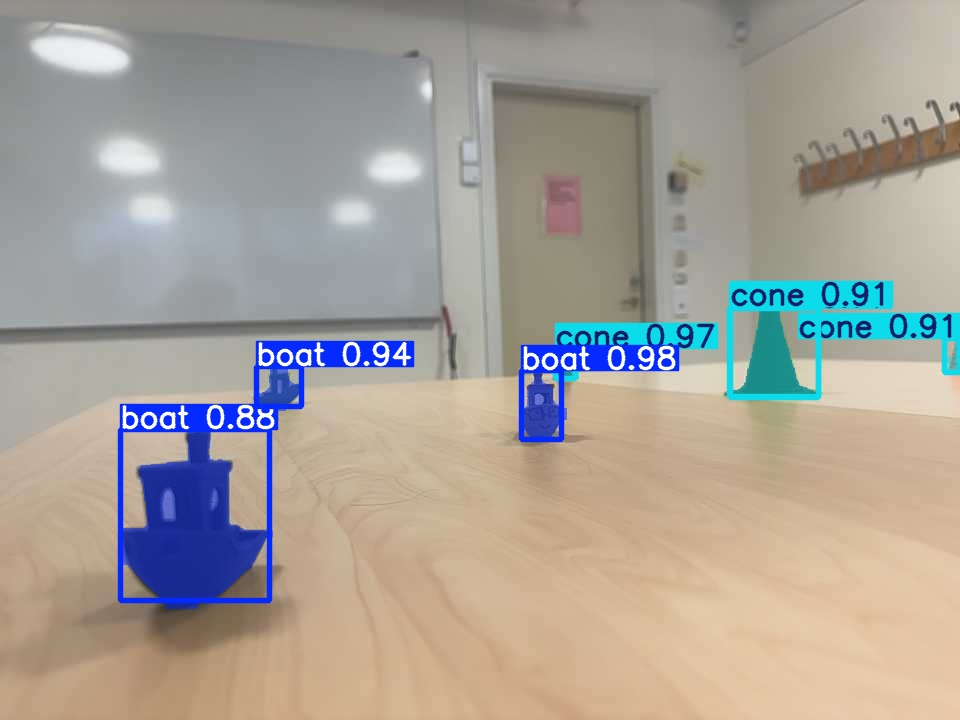

smoke test on: 2026-05-21--15-15-18_000005.jpg


In [23]:
import random, cv2
from IPython.display import Image as IPyImage, display

test_img = random.choice(list((DATASET / "images").glob("*.jpg")))
res = final(test_img, conf=0.25)
out_path = WEIGHTS_OUT / "smoke_test.jpg"
cv2.imwrite(str(out_path), res[0].plot())
display(IPyImage(str(out_path)))
print("smoke test on:", test_img.name)